# <font color='red'>Classification (part 1)</font>

The task is to teach a machine how to learn to recognize hand-written digits (MNIST).

# **Practice C1**: Set-up

In [ ]:
#numpy
import numpy as np
#sklearn
import sklearn
# matplotlib
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

# **Practice C2**: Import the data

In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Practice C3**: Inspect the dataset

Familiarize a bit with the shapes of X and y.

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_test.shape

(10000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
y_test.shape

(10000,)

If you  want to use it with sklearn or standard classifiers (as we are doing now), it is convenient to flatten the images.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
X_test.shape

(10000, 784)

NOTE: this is not necessary for $y$.

Now, explore your dataset.

In [ ]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

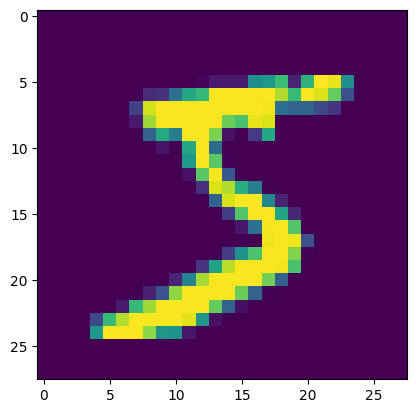

In [ ]:
some_digit = X_train[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image)

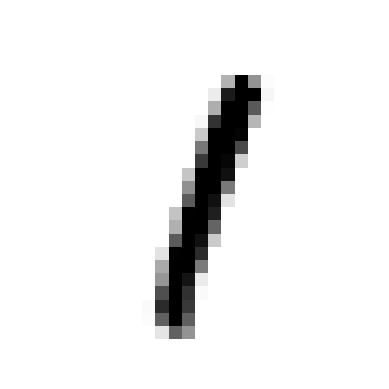

In [34]:
some_digit = X_test[5]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()


As expected, the label for this is:

In [15]:
y_train[0]

np.uint8(5)

I will only handle numbers, so good to check it is not a string.

# **Practice C4**: Build a binary classifier: a "5-detector"

Create the label vectors (for both the train and test set):

In [16]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [17]:
y_train_5.shape

(60000,)

In [18]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [19]:
y_train_5

array([ True, False, False, ...,  True, False, False])

In [20]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

# note: hyperparameters set to future default values in future versions on sklearn.

SGDClassifier(random_state=42)

Let's see on X_test, the first 100 hand-written digits, if I get some 5's, and if the model works.

In [21]:
for i in range(100):
    print(f"y_test[{i}] = {y_test[i]}")

y_test[0] = 7
y_test[1] = 2
y_test[2] = 1
y_test[3] = 0
y_test[4] = 4
y_test[5] = 1
y_test[6] = 4
y_test[7] = 9
y_test[8] = 5
y_test[9] = 9
y_test[10] = 0
y_test[11] = 6
y_test[12] = 9
y_test[13] = 0
y_test[14] = 1
y_test[15] = 5
y_test[16] = 9
y_test[17] = 7
y_test[18] = 3
y_test[19] = 4
y_test[20] = 9
y_test[21] = 6
y_test[22] = 6
y_test[23] = 5
y_test[24] = 4
y_test[25] = 0
y_test[26] = 7
y_test[27] = 4
y_test[28] = 0
y_test[29] = 1
y_test[30] = 3
y_test[31] = 1
y_test[32] = 3
y_test[33] = 4
y_test[34] = 7
y_test[35] = 2
y_test[36] = 7
y_test[37] = 1
y_test[38] = 2
y_test[39] = 1
y_test[40] = 1
y_test[41] = 7
y_test[42] = 4
y_test[43] = 2
y_test[44] = 3
y_test[45] = 5
y_test[46] = 1
y_test[47] = 2
y_test[48] = 4
y_test[49] = 4
y_test[50] = 6
y_test[51] = 3
y_test[52] = 5
y_test[53] = 5
y_test[54] = 6
y_test[55] = 0
y_test[56] = 4
y_test[57] = 1
y_test[58] = 9
y_test[59] = 5
y_test[60] = 7
y_test[61] = 8
y_test[62] = 9
y_test[63] = 3
y_test[64] = 7
y_test[65] = 4
y_test[66] = 6
y_tes

Let's check if the classifier we built above works for some examples:

In [22]:
sgd_clf.predict([X_test[50]]) # this is a 6, so NOT a 5

array([False])

In [23]:
sgd_clf.predict([X_test[51]]) # this is a 3, so NOT a 5

array([False])

In [24]:
sgd_clf.predict([X_test[52]]) # this is a 5

array([ True])

In [25]:
sgd_clf.predict([X_test[53]]) # this is a 5

array([ True])

But.. be careful...

In [26]:
sgd_clf.predict([X_test[8]]) # this is a 5, but it fails!

array([False])

So, on MOST cases, it works (good) - but sometimes it fails (it is expected..).

So, the actual question is: if (evidently!) not 100% accurate, how accurate is this model?

# **Practice C5**: Compute the accuracy

We opted for a train-test split, so most rapid is to ask for the score in this way:

In [35]:
sgd_clf.score(X_test, y_test_5)

0.9492

Actually, k-fold cross-validation would be similar or better - and would also allow you to get insight on its variance. Let's try it out.

Use `cross_val_score()` function in sklearn to evaluate your SGDClassifier model using k-fold cross-validation, with k=3, i.e. make k trainings: split the training set into k folds, train and make predictions and evaluate them on each fold using a model trained on the remaining folds.

In [36]:
y_train_5 = (y_train == 5)
y_train_5.shape

(60000,)

In [37]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# this trigger the training of cv=3 models, so it might take a while to complete!

array([0.95035, 0.96035, 0.9604 ])

As expected (see above), k-fold cross-validation is similar or better - and shows me some insights on its variance.

But... *Really?! Such a high accuracy at first attempt?! Are you sure this is reliable?*

# **Practice C6**: Confusion matrix: looking for a better performance metrics

In [38]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

# this trigger the training of cv=3 models, so it might take a while to complete!

In [39]:
type(y_pred)

numpy.ndarray

In [40]:
y_pred.shape

(60000,)

In [41]:
y_pred

array([ True, False, False, ...,  True, False, False])

In [42]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_pred)

array([[53892,   687],
       [ 1891,  3530]])

Other possible metrics are **precision** and **recall**, and often also the **F1** score:

In [43]:
from sklearn.metrics import precision_score
precision_score(y_train_5, y_pred)

0.8370879772350012

In [44]:
from sklearn.metrics import recall_score
recall_score(y_train_5, y_pred)

0.6511713705958311

In [45]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_pred)

0.7325171197343847

In [46]:
#create an array with, de-facto, the class probabilities
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [47]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

In [48]:
y_train_5

array([ True, False, False, ...,  True, False, False])

In [49]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

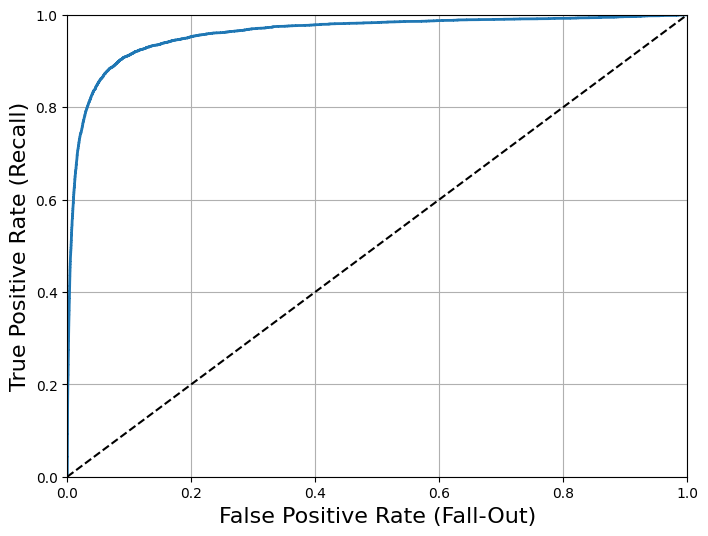

In [50]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

In [51]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

The AUC score should result as roughly 96-97%, when comparing your work with others'. It is a good result!